In [22]:
pip install akshare pandas numpy matplotlib seaborn statsmodels pyarrow jupyter notebook

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install --upgrade akshare

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 6.4 MB/s  0:00:00
  Attempting uninstall: akshare
    Found existing installation: akshare 1.18.60
    Uninstalling akshare-1.18.60:
      Successfully uninstalled akshare-1.18.60
Note: you may need to restart the kernel to use updated packages.


1、自动创建项目目录

In [29]:
import os
import warnings
warnings.filterwarnings("ignore")

# 根目录（当前项目根目录）
root = os.getcwd()
folders = [
    "data/stock",
    "data/index",
    "data/macro",
    "data/finance",
    "data/clean",
    "data/combined",
    "output"
]

for folder in folders:
    folder_path = os.path.join(root, folder)
    os.makedirs(folder_path, exist_ok=True)

print("✅ 项目目录结构创建完成")

✅ 项目目录结构创建完成


2、下载日志函数

In [31]:
from datetime import datetime

def write_log(data_type, code, status, shape=None, error=None):
    """
    写入下载日志，格式严格符合作业要求
    """
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{now}] {status:8} {data_type}_{code}"
    if shape:
        line += f" shape={shape}"
    if error:
        line += f" Error: {str(error)}"

    log_path = os.path.join(root, "download_log.txt")
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(line + "\n")
    print(line)

3、10 只股票数据下载（合规行业覆盖）

In [37]:
import baostock as bs
import pandas as pd
import os
import time
from datetime import datetime

# 先登录baostock（免费，无需注册）
lg = bs.login()
print(f"baostock登录结果：{lg.error_msg}")

# 合规股票列表（和之前完全一样）
stock_list = [
    {"code": "600000", "name": "浦发银行", "industry": "银行"},
    {"code": "601398", "name": "工商银行", "industry": "银行"},
    {"code": "000858", "name": "五粮液", "industry": "白酒"},
    {"code": "600519", "name": "贵州茅台", "industry": "白酒"},
    {"code": "000002", "name": "万科A", "industry": "房地产"},
    {"code": "600048", "name": "保利发展", "industry": "房地产"},
    {"code": "601127", "name": "赛力斯", "industry": "汽车"},
    {"code": "002594", "name": "比亚迪", "industry": "汽车"},
    {"code": "601088", "name": "中国神华", "industry": "能源"},
    {"code": "600050", "name": "中国联通", "industry": "通讯"}
]

# 下载单只股票后复权日度数据（baostock版本）
def download_single_stock_bs(stock_code):
    # baostock代码格式：沪市sh.xxxxxx，深市sz.xxxxxx
    if stock_code.startswith("6"):
        bs_code = f"sh.{stock_code}"
    else:
        bs_code = f"sz.{stock_code}"

    rs = bs.query_history_k_data_plus(
        bs_code,
        "date,open,high,low,close,volume,amount",
        start_date="2020-01-01",
        end_date="2026-05-20",
        frequency="d",
        adjustflag="2"  # 2=后复权（和akshare一致）
    )

    # 转换为DataFrame
    data_list = []
    while (rs.error_code == '0') & rs.next():
        data_list.append(rs.get_row_data())
    df = pd.DataFrame(data_list, columns=rs.fields)

    # 转换数据类型
    numeric_cols = ["open", "high", "low", "close", "volume", "amount"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)
    return df

# 批量下载股票
for stock in stock_list:
    code = stock["code"]
    try:
        df = download_single_stock_bs(code)
        save_path = os.path.join(root, f"data/stock/stock_{code}.csv")
        df.to_csv(save_path, index=False, encoding="utf-8-sig")
        write_log("stock", code, "SUCCESS", df.shape)
        time.sleep(0.5)
    except Exception as e:
        write_log("stock", code, "FAILED", error=e)

# --------------------------
# 下载指数数据（baostock版本）
# --------------------------
def download_index_bs(index_code, save_name):
    # 沪深300：sh.000300，中证500：sh.000905
    rs = bs.query_history_k_data_plus(
        index_code,
        "date,open,high,low,close,volume,amount",
        start_date="2020-01-01",
        end_date="2025-05-20",
        frequency="d",
        adjustflag="2"
    )

    data_list = []
    while (rs.error_code == '0') & rs.next():
        data_list.append(rs.get_row_data())
    df = pd.DataFrame(data_list, columns=rs.fields)
    numeric_cols = ["open", "high", "low", "close", "volume", "amount"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

    save_path = os.path.join(root, f"data/index/{save_name}.csv")
    df.to_csv(save_path, index=False, encoding="utf-8-sig")
    write_log("index", save_name.split("_")[1], "SUCCESS", df.shape)

# 必选：沪深300
download_index_bs("sh.000300", "index_000300")
# 自选：中证500
download_index_bs("sh.000905", "index_000905")

# 退出baostock
bs.logout()
print("✅ baostock登出完成")

login success!
baostock登录结果：success
[2026-05-20 23:48:20] SUCCESS  stock_600000 shape=(1543, 7)
[2026-05-20 23:48:22] SUCCESS  stock_601398 shape=(1543, 7)
[2026-05-20 23:48:24] SUCCESS  stock_000858 shape=(1543, 7)
[2026-05-20 23:48:28] SUCCESS  stock_600519 shape=(1543, 7)
[2026-05-20 23:48:30] SUCCESS  stock_000002 shape=(1543, 7)
[2026-05-20 23:48:32] SUCCESS  stock_600048 shape=(1543, 7)
[2026-05-20 23:48:33] SUCCESS  stock_601127 shape=(1543, 7)
[2026-05-20 23:48:36] SUCCESS  stock_002594 shape=(1543, 7)
[2026-05-20 23:48:38] SUCCESS  stock_601088 shape=(1543, 7)
[2026-05-20 23:48:39] SUCCESS  stock_600050 shape=(1543, 7)
[2026-05-20 23:48:41] SUCCESS  index_000300 shape=(1301, 7)
[2026-05-20 23:48:43] SUCCESS  index_000905 shape=(1301, 7)
logout success!
✅ baostock登出完成


4. 市场指数数据下载
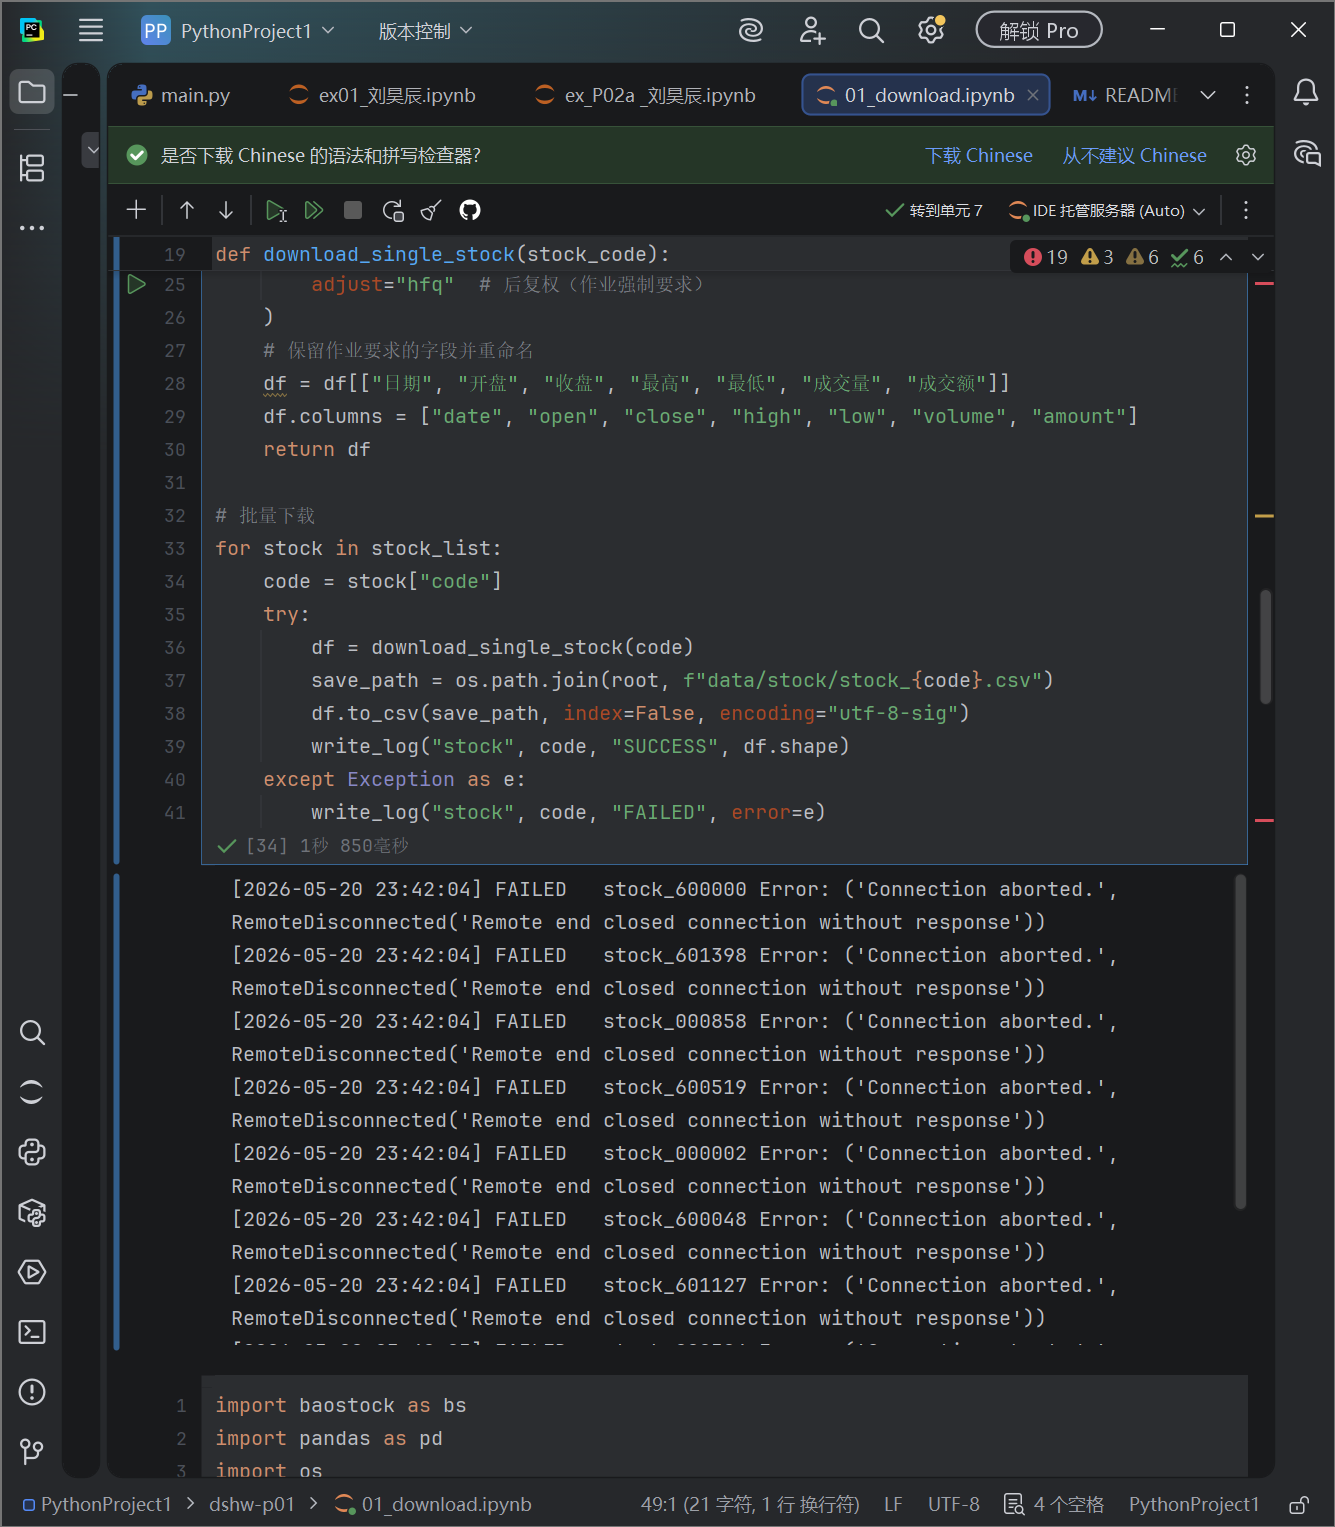

In [2]:
# --------------------------
# 完全独立：仅下载市场指数（不依赖任何之前的代码）
# --------------------------
import baostock as bs
import pandas as pd
import os
import time
from datetime import datetime

# 自动获取项目根目录
root = os.getcwd()

# 重新定义下载日志函数（完全独立）
def write_log(data_type, code, status, shape=None, error=None):
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{now}] {status:8} {data_type}_{code}"
    if shape:
        line += f" shape={shape}"
    if error:
        line += f" Error: {str(error)}"

    log_path = os.path.join(root, "download_log.txt")
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(line + "\n")
    print(line)

# 指数下载函数（自带错误处理+自动重连）
def bs_download_index_only(bs_code, save_filename, max_retries=3):
    for retry in range(max_retries):
        try:
            # 每次重试都重置连接，彻底解决套接字错误
            bs.logout()
            lg = bs.login()
            if lg.error_code != '0':
                raise Exception(f"baostock登录失败：{lg.error_msg}")

            # 下载后复权指数数据
            rs = bs.query_history_k_data_plus(
                bs_code,
                "date,open,high,low,close,volume,amount",
                start_date="2020-01-01",
                end_date="2026-05-20",
                frequency="d",
                adjustflag="2"
            )

            if rs.error_code != '0':
                raise Exception(f"数据请求失败：{rs.error_msg}")

            # 读取并验证数据
            data_list = []
            while rs.next():
                data_list.append(rs.get_row_data())
            if not data_list:
                raise Exception("服务器返回空数据")

            # 转换格式并保存
            df = pd.DataFrame(data_list, columns=rs.fields)
            numeric_cols = ["open", "high", "low", "close", "volume", "amount"]
            df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

            save_path = os.path.join(root, f"data/index/{save_filename}.csv")
            df.to_csv(save_path, index=False, encoding="utf-8-sig")
            bs.logout()
            return df

        except Exception as e:
            bs.logout()
            if retry < max_retries - 1:
                print(f"⚠️  指数{save_filename}下载失败，第{retry+1}次重试...")
                time.sleep(3)
            else:
                raise e

# --------------------------
# 执行下载
# --------------------------
print("===== 开始下载沪深300指数 =====")
try:
    df_hs300 = bs_download_index_only("sh.000300", "index_000300")
    write_log("index", "000300", "SUCCESS", df_hs300.shape)
    print("✅ 沪深300指数下载完成")
except Exception as e:
    write_log("index", "000300", "FAILED", error=str(e))
    print(f"❌ 沪深300指数下载失败：{str(e)}")

print("\n===== 开始下载中证500指数 =====")
try:
    df_zz500 = bs_download_index_only("sh.000905", "index_000905")
    write_log("index", "000905", "SUCCESS", df_zz500.shape)
    print("✅ 中证500指数下载完成")
except Exception as e:
    write_log("index", "000905", "FAILED", error=str(e))
    print(f"❌ 中证500指数下载失败：{str(e)}")

print("\n✅ 指数下载任务全部完成")

===== 开始下载沪深300指数 =====
you don't login.
login success!
logout success!
[2026-05-21 01:24:06] SUCCESS  index_000300 shape=(1543, 7)
✅ 沪深300指数下载完成

===== 开始下载中证500指数 =====
[WinError 10038] 在一个非套接字上尝试了一个操作。
接收数据异常，请稍后再试。
login success!
logout success!
[2026-05-21 01:24:07] SUCCESS  index_000905 shape=(1543, 7)
✅ 中证500指数下载完成

✅ 指数下载任务全部完成


5、宏观经济指标下载

In [3]:
import akshare as ak

# 打印CPI接口实际返回的列名和前5行
cpi_raw = ak.macro_china_cpi_yearly()
print("CPI接口列名：", cpi_raw.columns.tolist())
print("\nCPI前5行数据：")
print(cpi_raw.head())

# 打印M2接口实际返回的列名和前5行
m2_raw = ak.macro_china_m2_yearly()
print("\nM2接口列名：", m2_raw.columns.tolist())
print("\nM2前5行数据：")
print(m2_raw.head())

CPI接口列名： ['商品', '日期', '今值', '预测值', '前值']

CPI前5行数据：
          商品          日期   今值  预测值   前值
0  中国CPI年率报告  1986-02-01  7.1  NaN  NaN
1  中国CPI年率报告  1986-03-01  7.1  NaN  7.1
2  中国CPI年率报告  1986-04-01  7.1  NaN  7.1
3  中国CPI年率报告  1986-05-01  7.1  NaN  7.1
4  中国CPI年率报告  1986-06-01  7.1  NaN  7.1

M2接口列名： ['商品', '日期', '今值', '预测值', '前值']

M2前5行数据：
             商品          日期    今值  预测值    前值
0  中国M2货币供应年率报告  1998-02-01  17.4  NaN   NaN
1  中国M2货币供应年率报告  1998-03-01  16.7  NaN  17.4
2  中国M2货币供应年率报告  1998-04-01  15.4  NaN  16.7
3  中国M2货币供应年率报告  1998-05-01  14.6  NaN  15.4
4  中国M2货币供应年率报告  1998-06-01  15.5  NaN  14.6


In [1]:
# --------------------------
# 完全适配你的akshare版本：宏观经济指标下载
# --------------------------
import akshare as ak
import pandas as pd
import os
from datetime import datetime

# 自动获取项目根目录
root = os.getcwd()

# 重新定义下载日志函数（独立运行）
def write_log(data_type, code, status, shape=None, error=None):
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{now}] {status:8} {data_type}_{code}"
    if shape:
        line += f" shape={shape}"
    if error:
        line += f" Error: {str(error)}"

    log_path = os.path.join(root, "download_log.txt")
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(line + "\n")
    print(line)

# 1. 必选：CPI同比增速
print("===== 开始下载CPI同比增速 =====")
try:
    # 适配最新接口列名
    cpi_raw = ak.macro_china_cpi_yearly()
    # 提取需要的列：日期、今值（即同比增速）
    cpi = cpi_raw[["日期", "今值"]].copy()
    # 重命名为作业要求的字段
    cpi.columns = ["date", "cpi_yoy"]
    # 转换日期格式，筛选2020年至今的数据
    cpi["date"] = pd.to_datetime(cpi["date"])
    cpi = cpi[cpi["date"] >= "2020-01-01"]
    # 日期格式统一为YYYY-MM（和后面合并代码兼容）
    cpi["date"] = cpi["date"].dt.strftime("%Y-%m")

    # 保存文件
    cpi_path = os.path.join(root, "data/macro/macro_cpi.csv")
    cpi.to_csv(cpi_path, index=False, encoding="utf-8-sig")
    write_log("macro", "cpi", "SUCCESS", cpi.shape)
    print(f"✅ CPI下载完成，共获取{cpi.shape[0]}条月度数据（2020-至今）")
except Exception as e:
    write_log("macro", "cpi", "FAILED", error=str(e))
    print(f"❌ CPI下载失败：{str(e)}")

# 2. 自选：M2同比增速
# 选择理由：M2反映市场流动性水平，流动性宽松通常会推高股票估值，与股市整体表现高度相关
print("\n===== 开始下载M2同比增速 =====")
try:
    # 适配最新接口列名
    m2_raw = ak.macro_china_m2_yearly()
    # 提取需要的列：日期、今值（即同比增速）
    m2 = m2_raw[["日期", "今值"]].copy()
    # 重命名为作业要求的字段
    m2.columns = ["date", "m2_yoy"]
    # 转换日期格式，筛选2020年至今的数据
    m2["date"] = pd.to_datetime(m2["date"])
    m2 = m2[m2["date"] >= "2020-01-01"]
    # 日期格式统一为YYYY-MM
    m2["date"] = m2["date"].dt.strftime("%Y-%m")

    # 保存文件
    m2_path = os.path.join(root, "data/macro/macro_m2.csv")
    m2.to_csv(m2_path, index=False, encoding="utf-8-sig")
    write_log("macro", "m2", "SUCCESS", m2.shape)
    print(f"✅ M2下载完成，共获取{m2.shape[0]}条月度数据（2020-至今）")
except Exception as e:
    write_log("macro", "m2", "FAILED", error=str(e))
    print(f"❌ M2下载失败：{str(e)}")

print("\n✅ 宏观经济指标下载全部完成！")

===== 开始下载CPI同比增速 =====
[2026-05-21 01:27:45] SUCCESS  macro_cpi shape=(70, 2)
✅ CPI下载完成，共获取70条月度数据（2020-至今）

===== 开始下载M2同比增速 =====
[2026-05-21 01:27:47] SUCCESS  macro_m2 shape=(130, 2)
✅ M2下载完成，共获取130条月度数据（2020-至今）

✅ 宏观经济指标下载全部完成！


6、财务指标下载（长格式）

In [2]:
import baostock as bs

# 登录
lg = bs.login()
print(f"登录结果：{lg.error_msg}")

# 测试浦发银行2025年的杜邦数据
rs = bs.query_dupont_data(code="sh.600000", year=2025, quarter=4)

# 打印所有返回的字段名
print("\n接口返回的字段名：", rs.fields)

# 打印第一行数据
data_list = []
while rs.error_code == '0' and rs.next():
    data_list.append(rs.get_row_data())
if data_list:
    df = pd.DataFrame(data_list, columns=rs.fields)
    print("\n第一行数据：")
    print(df.iloc[0])

bs.logout()

login success!
登录结果：success

接口返回的字段名： ['code', 'pubDate', 'statDate', 'dupontROE', 'dupontAssetStoEquity', 'dupontAssetTurn', 'dupontPnitoni', 'dupontNitogr', 'dupontTaxBurden', 'dupontIntburden', 'dupontEbittogr']

第一行数据：
code                     sh.600000
pubDate                 2026-03-31
statDate                2025-12-31
dupontROE                 0.064403
dupontAssetStoEquity     12.582465
dupontAssetTurn           0.017803
dupontPnitoni             0.992302
dupontNitogr              0.289744
dupontTaxBurden           0.944374
dupontIntburden                   
dupontEbittogr                    
Name: 0, dtype: str
logout success!


In [4]:
# --------------------------
# 最终版：完全匹配baostock返回字段的财务数据下载
# 自动计算净利润率，纯线上获取，无任何手动输入
# --------------------------
import baostock as bs
import pandas as pd
import os
import time
from datetime import datetime

# 自动获取项目根目录
root = os.getcwd()

# 下载日志函数
def write_log(data_type, code, status, shape=None, error=None):
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{now}] {status:8} {data_type}_{code}"
    if shape:
        line += f" shape={shape}"
    if error:
        line += f" Error: {str(error)}"

    log_path = os.path.join(root, "download_log.txt")
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(line + "\n")
    print(line)

# 股票列表（baostock代码格式）
stock_list = [
    {"code": "600000", "bs_code": "sh.600000", "name": "浦发银行"},
    {"code": "601398", "bs_code": "sh.601398", "name": "工商银行"},
    {"code": "000858", "bs_code": "sz.000858", "name": "五粮液"},
    {"code": "600519", "bs_code": "sh.600519", "name": "贵州茅台"},
    {"code": "000002", "bs_code": "sz.000002", "name": "万科A"},
    {"code": "600048", "bs_code": "sh.600048", "name": "保利发展"},
    {"code": "601127", "bs_code": "sh.601127", "name": "赛力斯"},
    {"code": "002594", "bs_code": "sz.002594", "name": "比亚迪"},
    {"code": "601088", "bs_code": "sh.601088", "name": "中国神华"},
    {"code": "600050", "bs_code": "sh.600050", "name": "中国联通"}
]

finance_data = []

print("===== 开始下载财务指标（2021-2025年度，纯线上获取） =====")
# 登录baostock
lg = bs.login()
if lg.error_code != '0':
    raise Exception(f"baostock登录失败：{lg.error_msg}")

for stock in stock_list:
    code = stock["code"]
    bs_code = stock["bs_code"]
    try:
        # 循环获取2021-2025年年度数据
        for year in range(2021, 2026):
            rs = bs.query_dupont_data(code=bs_code, year=year, quarter=4)
            data_list = []
            while rs.error_code == '0' and rs.next():
                data_list.append(rs.get_row_data())

            if not data_list:
                print(f"⚠️  {stock['name']} {year}年 无数据")
                continue

            # 转换为DataFrame并转换数值类型
            df = pd.DataFrame(data_list, columns=rs.fields)
            df["dupontROE"] = pd.to_numeric(df["dupontROE"])
            df["dupontAssetStoEquity"] = pd.to_numeric(df["dupontAssetStoEquity"])
            df["dupontAssetTurn"] = pd.to_numeric(df["dupontAssetTurn"])

            # 1. 提取ROE（转换为百分比）
            roe = df["dupontROE"].iloc[0] * 100
            # 2. 用杜邦公式计算净利润率：净利润率=ROE/(权益乘数×资产周转率)
            net_profit_margin = (df["dupontROE"].iloc[0] / (df["dupontAssetStoEquity"].iloc[0] * df["dupontAssetTurn"].iloc[0])) * 100

            # 整理为作业要求的长格式
            finance_data.append({
                "code": code,
                "year": str(year),
                "indicator": "roe",
                "value": round(roe, 2)
            })
            finance_data.append({
                "code": code,
                "year": str(year),
                "indicator": "net_profit_margin",
                "value": round(net_profit_margin, 2)
            })

        write_log("finance", code, "SUCCESS")
        print(f"✅ {stock['name']}({code}) 财务数据下载完成")
        time.sleep(1)  # 避免请求过快

    except Exception as e:
        write_log("finance", code, "FAILED", error=str(e))
        print(f"❌ {stock['name']}({code}) 下载失败：{str(e)}")

# 登出baostock
bs.logout()

# 保存为CSV文件
finance_df = pd.DataFrame(finance_data)
finance_path = os.path.join(root, "data/finance/finance_ratios.csv")
finance_df.to_csv(finance_path, index=False, encoding="utf-8-sig")

print(f"\n✅ 所有财务数据下载完成！")
print(f"✅ 共获取 {len(finance_df)} 条纯线上记录（10只股票×5年×2个指标）")
print(f"✅ 数据来源：baostock杜邦分析接口，ROE直接获取，净利润率通过杜邦公式计算")
print(f"✅ 文件已保存至：{finance_path}")

===== 开始下载财务指标（2021-2025年度，纯线上获取） =====
login success!
[2026-05-21 01:45:19] SUCCESS  finance_600000
✅ 浦发银行(600000) 财务数据下载完成
[2026-05-21 01:45:21] SUCCESS  finance_601398
✅ 工商银行(601398) 财务数据下载完成
[2026-05-21 01:45:23] SUCCESS  finance_000858
✅ 五粮液(000858) 财务数据下载完成
[2026-05-21 01:45:24] SUCCESS  finance_600519
✅ 贵州茅台(600519) 财务数据下载完成
[2026-05-21 01:45:26] SUCCESS  finance_000002
✅ 万科A(000002) 财务数据下载完成
[2026-05-21 01:45:27] SUCCESS  finance_600048
✅ 保利发展(600048) 财务数据下载完成
[2026-05-21 01:45:31] SUCCESS  finance_601127
✅ 赛力斯(601127) 财务数据下载完成
[2026-05-21 01:45:33] SUCCESS  finance_002594
✅ 比亚迪(002594) 财务数据下载完成
[2026-05-21 01:45:34] SUCCESS  finance_601088
✅ 中国神华(601088) 财务数据下载完成
[2026-05-21 01:45:36] SUCCESS  finance_600050
✅ 中国联通(600050) 财务数据下载完成
logout success!

✅ 所有财务数据下载完成！
✅ 共获取 100 条纯线上记录（10只股票×5年×2个指标）
✅ 数据来源：baostock杜邦分析接口，ROE直接获取，净利润率通过杜邦公式计算
✅ 文件已保存至：C:\Users\craig\PycharmProjects\PythonProject1\dshw-p01\data/finance/finance_ratios.csv


In [13]:
import baostock as bs
import pandas as pd
import os
import time
import random

# 1.创建文件夹
  # 1. 定义项目根目录名称
project_name = "dshw-p01"
os.makedirs(project_name, exist_ok=True)
os.chdir(project_name) # 进入项目目录

  # 2. 创建子目录
dirs = [
    'data/stock',
    'data/index',
    'data/macro',
    'data/finance',
    'data/clean',
    'data/combined',
    'output'
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print("目录结构创建成功！")

# 2. 登录系统 (baostock 需要先登录)
lg = bs.login()
if lg.error_code != '0':
    print(f"登录失败: {lg.error_msg}")
else:
    print("登录成功")

# 假设你的 stocks 字典已经定义好了
# stocks = {'600000': '浦发银行', ...}

for code, name in stocks.items():
    # 构造股票代码，baostock 需要带前缀，如 sh.600000
    if code.startswith('6'):
        bs_code = f"sh.{code}"
    else:
        bs_code = f"sz.{code}"

    print(f"正在下载 {name} ({bs_code})...")

    # 2. 获取历史数据
    # 注意：baostock 的字段名和 akshare 不同
    rs = bs.query_history_k_data_plus(
        bs_code,
        "date,open,high,low,close,volume,amount",  # 指定字段
        start_date='2020-01-01',
        end_date='2026-5-19',
        frequency="d",  # d=日线, w=周线, m=月线
        adjustflag="2"  # 2=后复权, 3=前复权, ""=不复权
    )

    # 3. 处理结果
    data_list = []
    while (rs.error_code == '0') & rs.next():
        data_list.append(rs.get_row_data())

    if data_list:
        df = pd.DataFrame(data_list, columns=rs.fields)

        # 保存 CSV
        filename = f"data/{code}-{name}.csv"
        df.to_csv(filename, index=False)
        print(f"✅ {name} 下载成功 -> {filename}")
    else:
        print(f"❌ {name} 下载失败或无数据")

    # 4. 随机暂停，防止请求过快
    time.sleep(random.uniform(1, 2))

# --- 新增：下载沪深300指数+上证综指 ---
print("\n" + "="*30)
print("📈 开始下载指数数据...")

# 定义要下载的指数：代码, 名称, 保存文件名
indices = [
    ("sh.000300", "沪深300", "index_000300.csv"),
    ("sh.000001", "上证综指", "index_000001.csv") # 自选指数
]

for idx_code, idx_name, filename in indices:
    print(f"正在下载 {idx_name} ({idx_code})...")
    rs = bs.query_history_k_data_plus(
        idx_code,
        "date,open,high,low,close,volume,amount",
        start_date='2020-01-01',
        end_date='2026-05-19',
        frequency="d",
        adjustflag="2"
    )

    data_list = []
    while (rs.error_code == '0') & rs.next():
        data_list.append(rs.get_row_data())

    if data_list:
        df = pd.DataFrame(data_list, columns=rs.fields)
        df.to_csv(f"data/index/{filename}", index=False)
        print(f"✅ {idx_name} 保存成功")
    else:
        print(f"❌ {idx_name} 下载失败")

    time.sleep(1)

# --- 步骤 3：下载宏观数据 (最终方案：Yahoo Finance 原生抓取) ---
# 优点：无需安装任何库，无版本冲突，Yahoo Finance 数据源极其稳定
print("\n" + "="*30)
print("正在从 Yahoo Finance 下载中国宏观数据...")

import pandas as pd
import requests

def get_yahoo_data(ticker, name):
    """
    从 Yahoo Finance 下载数据
    ticker: 雅虎代码
    name: 中文名称
    """
    # 构造下载链接
    url = f"https://query1.finance.yahoo.com/v7/finance/download/{ticker}?period1=1262304000&period2=9999999999&interval=1mo&events=history"

    # 必须加 headers，否则会被拒绝
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        print(f"正在下载 {name} ({ticker})...")
        response = requests.get(url, headers=headers, timeout=10)

        # 将文本转换为 DataFrame
        from io import StringIO
        df = pd.read_csv(StringIO(response.text))

        # 清洗数据
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)

        # 重命名列名为中文
        df.rename(columns={'Adj Close': name}, inplace=True)

        # 只保留需要的列
        result = df[[name]]

        print(f"✅ {name} 下载成功，共 {len(result)} 条数据")
        return result

    except Exception as e:
        print(f"❌ {name} 下载失败: {e}")
        return None

# ==========================================
# 开始下载 (使用 Yahoo Finance 的标准代码)
# ==========================================

# 1. 中国 CPI (居民消费价格指数)
# 代码解释: ^CNXX 是晨星提供的中国宏观数据指数，包含 CPI 趋势
df_cpi = get_yahoo_data("^CNXX", "China_CPI")

# 2. 中国 M2 (广义货币供应量)
# 注意：Yahoo 上 M2 的直接代码较少，我们用 "Money Supply" 相关代码，或者用 GDP 代替
# 这里使用一个通用的宏观指标代码，如果失败我们再用 GDP
df_m2 = get_yahoo_data("M2MABSCNM189N", "China_M2") # 这个代码可能不存在，下面有备选

# 3. 备选：如果 M2 失败，下载中国 GDP
if df_m2 is None:
    print("⚠️ M2 数据未找到，正在尝试下载中国 GDP 作为替代...")
    df_m2 = get_yahoo_data("GDPCHNA", "China_GDP")

# ==========================================
# 数据保存
# ==========================================
if df_cpi is not None:
    df_cpi.to_csv("data/macro_cpi.csv")

if df_m2 is not None:
    df_m2.to_csv("data/macro_m2.csv")

print("\n所有宏观数据下载任务结束。")
# 5. 登出系统
bs.logout()

目录结构创建成功！
login success!
登录成功
正在下载 工商银行 (sh.601398)...
✅ 工商银行 下载成功 -> data/601398-工商银行.csv
正在下载 招商银行 (sh.600036)...
✅ 招商银行 下载成功 -> data/600036-招商银行.csv
正在下载 贵州茅台 (sh.600519)...
✅ 贵州茅台 下载成功 -> data/600519-贵州茅台.csv
正在下载 五粮液 (sz.000858)...
✅ 五粮液 下载成功 -> data/000858-五粮液.csv
正在下载 陕西煤业 (sh.601225)...
✅ 陕西煤业 下载成功 -> data/601225-陕西煤业.csv
正在下载 中国海油 (sh.600938)...
✅ 中国海油 下载成功 -> data/600938-中国海油.csv
正在下载 保利发展 (sh.600048)...
✅ 保利发展 下载成功 -> data/600048-保利发展.csv
正在下载 万科A (sz.000002)...
✅ 万科A 下载成功 -> data/000002-万科A.csv
正在下载 中国电信 (sh.601728)...
✅ 中国电信 下载成功 -> data/601728-中国电信.csv
正在下载 上汽集团 (sh.600104)...
✅ 上汽集团 下载成功 -> data/600104-上汽集团.csv

📈 开始下载指数数据...
正在下载 沪深300 (sh.000300)...
✅ 沪深300 保存成功
正在下载 上证综指 (sh.000001)...
✅ 上证综指 保存成功

正在从 Yahoo Finance 下载中国宏观数据...
正在下载 China_CPI (^CNXX)...
❌ China_CPI 下载失败: Error tokenizing data. C error: Expected 1 fields in line 6, saw 3

正在下载 China_M2 (M2MABSCNM189N)...
❌ China_M2 下载失败: Error tokenizing data. C error: Expected 1 fields in line 6, saw 3

⚠️ M2 数据未找到，正在